# Proyecto Final: Identificación de Operadores Ineficaces

## Contexto del negocio

El servicio de telefonía virtual **CallMeMaybe** permite a empresas gestionar grandes volúmenes de llamadas entrantes y salientes a través de múltiples operadores.

Actualmente, la compañía busca desarrollar una funcionalidad que permita a supervisores identificar **operadores ineficaces**, con el objetivo de mejorar la eficiencia operativa, reducir tiempos de espera y optimizar la atención al cliente.

---

## Objetivo del análisis

Identificar operadores ineficaces a partir de datos históricos de llamadas, considerando los siguientes criterios:

- Alta proporción de llamadas entrantes perdidas  
- Tiempos de espera elevados en llamadas entrantes  
- Bajo volumen de llamadas salientes (cuando aplica)  

---

## Definición del problema

Un desafío clave es que el concepto de “ineficiencia” no está definido de manera cuantitativa. Por lo tanto, será necesario:

- Construir métricas relevantes a partir de los datos  
- Comparar el desempeño relativo entre operadores  
- Definir criterios objetivos para clasificar operadores como ineficaces  

---

## Enfoque del análisis

El análisis se desarrollará en las siguientes etapas:

1. Preparación y limpieza de datos  
2. Construcción de métricas clave por operador  
3. Análisis exploratorio (EDA)  
4. Definición de criterios de ineficiencia  
5. Identificación de operadores ineficaces  
6. Validación mediante pruebas estadísticas  
7. Conclusiones y recomendaciones de negocio  

---

## Descripción de los datos

Se utilizarán dos conjuntos de datos:

### telecom_dataset_us.csv
Contiene información detallada de llamadas:
- `user_id`: ID del cliente
- `date`: fecha de la llamada
- `direction`: tipo de llamada (`in` o `out`)
- `internal`: si la llamada es interna
- `operator_id`: identificador del operador
- `is_missed_call`: indicador de llamada perdida
- `calls_count`: número de llamadas
- `call_duration`: duración sin tiempo de espera
- `total_call_duration`: duración total (incluye espera)

### telecom_clients_us.csv
Contiene información de los clientes:
- `user_id`: ID del cliente
- `tariff_plan`: plan tarifario
- `date_start`: fecha de registro

---

##  Consideraciones iniciales

Antes de comenzar el análisis, es importante tener en cuenta:

- Existen diferentes tipos de operadores (entrantes, salientes, mixtos)
- Las métricas deben normalizarse (no usar solo valores absolutos)
- El tiempo de espera deberá calcularse a partir de las variables disponibles
- Operadores con bajo volumen de datos pueden afectar el análisis

---

# PASO 2 — CARGA Y LIMPIEZA DE DATOS
## Preparación y limpieza de datos

En esta sección se realizará la carga de los datasets y una inspección inicial para garantizar la calidad de los datos antes del análisis.

Se revisarán:

- Tipos de datos
- Valores nulos
- Duplicados
- Coherencia general de las variables

In [2]:
# Importación de librerías
import pandas as pd
import numpy as np

# Carga de datos
calls = pd.read_csv('/datasets/telecom_dataset_us.csv')
clients = pd.read_csv('/datasets/telecom_clients_us.csv')

# Vista inicial
display(calls.head())
display(clients.head())

# Información general
print(" Dataset de llamadas")
display(calls.info())

print("\n Dataset de clientes")
display(clients.info())

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


 Dataset de llamadas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


None


 Dataset de clientes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


None

## Revisión de valores nulos

In [3]:
# Valores nulos
calls.isna().sum()
clients.isna().sum()

user_id        0
tariff_plan    0
date_start     0
dtype: int64

## Revisión de duplicados

In [4]:
# Duplicados
print("Duplicados en calls:", calls.duplicated().sum())
print("Duplicados en clients:", clients.duplicated().sum())

Duplicados en calls: 4900
Duplicados en clients: 0


## Conversión de tipos de datos

In [5]:
# Convertir fechas a datetime
calls['date'] = pd.to_datetime(calls['date'])
clients['date_start'] = pd.to_datetime(clients['date_start'])

## Observaciones iniciales

En esta etapa se busca identificar posibles problemas en los datos, como:

- Registros incompletos
- Tipos de datos incorrectos
- Posibles inconsistencias

Estos hallazgos serán considerados en las siguientes etapas del análisis.

# PASO 3 — FEATURE ENGINEERING
## Construcción de métricas (Feature Engineering)

En esta sección se crearán variables derivadas que permitirán evaluar el desempeño de cada operador de manera objetiva.

Dado que los datos contienen información agregada (`calls_count`), es fundamental utilizar esta variable correctamente para evitar distorsiones en el análisis.

---

## Objetivo

Construir métricas clave por operador que permitan medir:

- Volumen de actividad
- Eficiencia en manejo de llamadas entrantes
- Nivel de pérdida de llamadas
- Desempeño en llamadas salientes
- Tiempo de espera promedio

---

## Consideraciones clave

- Cada fila puede representar múltiples llamadas (`calls_count`)
- Las métricas deben calcularse ponderadas por número de llamadas
- Es necesario separar llamadas entrantes (`in`) y salientes (`out`)
- El tiempo de espera no está explícito y debe ser calculado

---

## Crear variables base

In [6]:
# Crear tiempo de espera (waiting time)
calls['waiting_time'] = calls['total_call_duration'] - calls['call_duration']

# Asegurar que no haya valores negativos
calls['waiting_time'] = calls['waiting_time'].clip(lower=0)

## Separación de tipos de llamadas

Para analizar correctamente el desempeño de los operadores, se separan las llamadas en:

- Entrantes (`in`)
- Salientes (`out`)

In [7]:
# Crear columnas auxiliares
calls['calls_in'] = np.where(calls['direction'] == 'in', calls['calls_count'], 0)
calls['calls_out'] = np.where(calls['direction'] == 'out', calls['calls_count'], 0)

calls['missed_calls'] = np.where(calls['is_missed_call'], calls['calls_count'], 0)

## Agregación por operador

Se agrupan los datos por `operator_id` para construir métricas consolidadas por operador.

In [8]:
operator_metrics = calls.groupby('operator_id').agg({
    'calls_count': 'sum',
    'calls_in': 'sum',
    'calls_out': 'sum',
    'missed_calls': 'sum',
    'call_duration': 'sum',
    'total_call_duration': 'sum',
    'waiting_time': 'sum'
}).reset_index()

## Creación de métricas de desempeño

In [9]:
# Evitar divisiones por cero
operator_metrics['missed_rate'] = (
    operator_metrics['missed_calls'] / operator_metrics['calls_count']
)

operator_metrics['avg_waiting_time'] = (
    operator_metrics['waiting_time'] / operator_metrics['calls_count']
)

operator_metrics['avg_call_duration'] = (
    operator_metrics['call_duration'] / operator_metrics['calls_count']
)

## Clasificación de operadores

No todos los operadores tienen el mismo rol. Por ello, se clasifican en función de su tipo de actividad:

- Operadores entrantes: mayor volumen de llamadas entrantes  
- Operadores salientes: mayor volumen de llamadas salientes  
- Operadores mixtos: combinación de ambos  

In [10]:
def classify_operator(row):
    if row['calls_in'] > row['calls_out'] * 1.5:
        return 'inbound'
    elif row['calls_out'] > row['calls_in'] * 1.5:
        return 'outbound'
    else:
        return 'mixed'

operator_metrics['operator_type'] = operator_metrics.apply(classify_operator, axis=1)

## Vista general de métricas por operador

In [11]:
display(operator_metrics.head())

operator_metrics.describe()

,operator_id,calls_count,calls_in,calls_out,missed_calls,call_duration,total_call_duration,waiting_time,missed_rate,avg_waiting_time,avg_call_duration,operator_type
0,879896.0,1131,60,1071,255,83261,97427,14166,0.225464,12.525199,73.617153,outbound
1,879898.0,7974,118,7856,2594,278878,391850,112972,0.325307,14.167545,34.973414,outbound
2,880020.0,54,8,46,30,2290,2624,334,0.555556,6.185185,42.407407,outbound
3,880022.0,219,8,211,118,18304,22679,4375,0.538813,19.977169,83.579909,outbound
4,880026.0,2439,25,2414,696,169674,193666,23992,0.285363,9.836818,69.567036,outbound


,operator_id,calls_count,calls_in,calls_out,missed_calls,call_duration,total_call_duration,waiting_time,missed_rate,avg_waiting_time,avg_call_duration
count,1092.000000,1092.000000,1092.000000,1092.000000,1092.000000,1.092000e+03,1.092000e+03,1.092000e+03,1092.000000,1092.000000,1092.000000
mean,925517.543956,707.911172,94.959707,612.951465,274.392857,4.228623e+04,5.536771e+04,1.308149e+04,0.290327,16.457491,74.227915
std,22854.532209,3181.539177,333.535262,3103.139223,1414.754915,1.915676e+05,2.607962e+05,7.146725e+04,0.248426,8.240237,79.350802
min,879896.000000,1.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,906393.500000,11.000000,0.000000,2.000000,1.000000,4.797500e+02,6.695000e+02,1.515000e+02,0.061557,11.460714,31.558993
50%,925105.000000,78.500000,5.000000,36.500000,15.000000,5.985000e+03,7.216500e+03,1.113000e+03,0.270196,15.827438,59.285948
75%,944211.500000,558.750000,38.250000,388.750000,146.000000,3.712275e+04,4.764900e+04,8.573500e+03,0.428571,20.006402,92.728590
max,973286.000000,66049.000000,5221.000000,64897.000000,27388.000000,4.663954e+06,6.200335e+06,1.586416e+06,1.000000,62.333333,1306.000000


# PASO 4 — ANÁLISIS EXPLORATORIO (EDA)

En esta sección se analizan las métricas construidas para entender el comportamiento de los operadores y detectar patrones relevantes.

El objetivo no es solo visualizar datos, sino responder preguntas clave que permitan:

- Identificar problemas operativos
- Detectar outliers
- Entender la variabilidad entre operadores
- Preparar la definición de ineficiencia

## Distribución del volumen de llamadas por operador

Se analiza cómo se distribuye el número total de llamadas entre operadores para identificar:

- Operadores con muy baja actividad (potencial ruido)
- Operadores con alta carga de trabajo

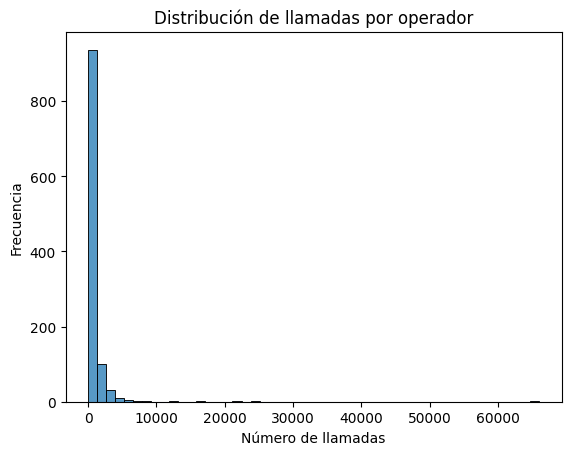

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(operator_metrics['calls_count'], bins=50)

plt.title('Distribución de llamadas por operador')
plt.xlabel('Número de llamadas')
plt.ylabel('Frecuencia')

plt.show()

### Observaciones

- Existe una alta dispersión en el volumen de llamadas
- Se identifican operadores con muy pocas llamadas (posible exclusión posterior)

## 4.2 Tasa de llamadas perdidas
Se analiza la proporción de llamadas perdidas por operador, ya que es uno de los principales indicadores de ineficiencia.

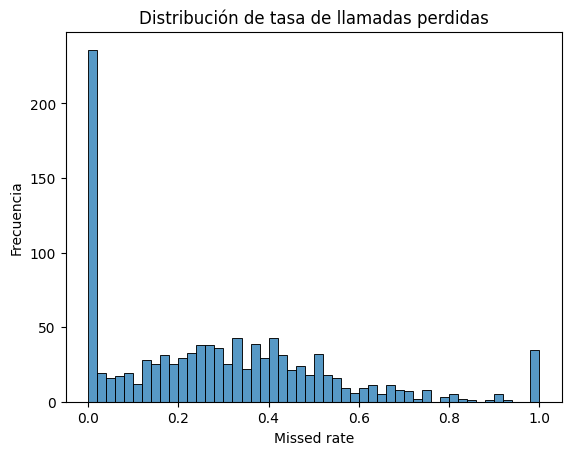

In [13]:
plt.figure()
sns.histplot(operator_metrics['missed_rate'], bins=50)

plt.title('Distribución de tasa de llamadas perdidas')
plt.xlabel('Missed rate')
plt.ylabel('Frecuencia')

plt.show()

### Observaciones

- La mayoría de operadores presenta tasas bajas
- Se observan outliers con tasas significativamente altas

## 4.3 Tiempo promedio de espera
El tiempo de espera impacta directamente la experiencia del cliente. Se analiza su distribución entre operadores.

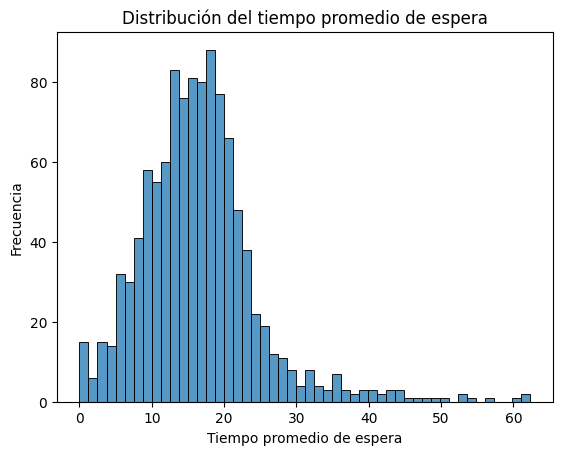

In [14]:
plt.figure()
sns.histplot(operator_metrics['avg_waiting_time'], bins=50)

plt.title('Distribución del tiempo promedio de espera')
plt.xlabel('Tiempo promedio de espera')
plt.ylabel('Frecuencia')

plt.show()

### Observaciones

- Se observa variabilidad importante entre operadores
- Algunos presentan tiempos de espera significativamente altos

## 4.4 Relación entre variables (CLAVE)
Se analiza si existe relación entre:

- Alta tasa de llamadas perdidas
- Mayor tiempo de espera

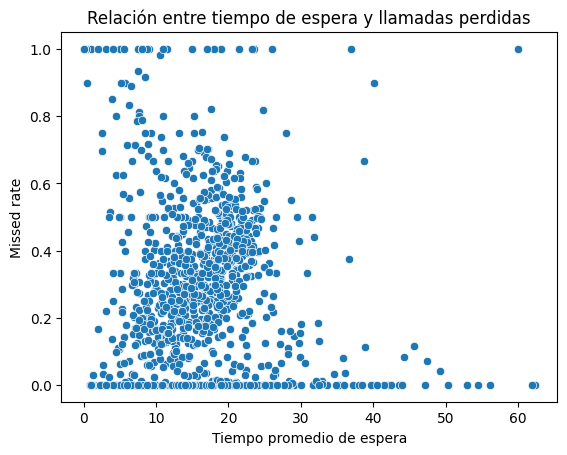

In [16]:
plt.figure()
sns.scatterplot(
    data=operator_metrics,
    x='avg_waiting_time',
    y='missed_rate'
)

plt.title('Relación entre tiempo de espera y llamadas perdidas')
plt.xlabel('Tiempo promedio de espera')
plt.ylabel('Missed rate')

plt.show()

### Observaciones

- Se busca identificar si existe correlación positiva
- Operadores en la esquina superior derecha podrían ser críticos

## 4.5 Comparación por tipo de operador
Se analiza si el desempeño varía según el tipo de operador:
- inbound
- outbound
- mixed

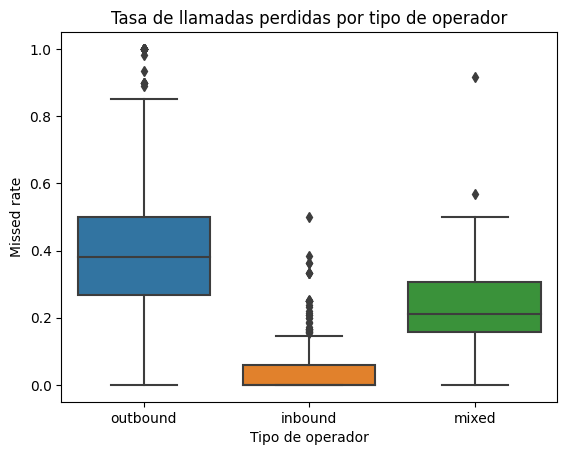

In [17]:
plt.figure()
sns.boxplot(
    data=operator_metrics,
    x='operator_type',
    y='missed_rate'
)

plt.title('Tasa de llamadas perdidas por tipo de operador')
plt.xlabel('Tipo de operador')
plt.ylabel('Missed rate')

plt.show()

### Observaciones

- Se identifican diferencias entre tipos de operador
- Esto es clave para no evaluar a todos con el mismo criterio

## 4.6 Identificación de outliers
Se identifican operadores con valores extremos que podrían indicar problemas graves o datos anómalos.

In [18]:
# Operadores con mayor tasa de llamadas perdidas
top_missed = operator_metrics.sort_values(by='missed_rate', ascending=False).head(10)

# Operadores con mayor tiempo de espera
top_wait = operator_metrics.sort_values(by='avg_waiting_time', ascending=False).head(10)

display(top_missed)
display(top_wait)

,operator_id,calls_count,calls_in,calls_out,missed_calls,call_duration,total_call_duration,waiting_time,missed_rate,avg_waiting_time,avg_call_duration,operator_type
569,928282.0,2,0,2,2,0,16,16,1.0,8.000000,0.0,outbound
386,914626.0,1,0,1,1,0,0,0,1.0,0.000000,0.0,outbound
324,909308.0,15,0,15,15,0,349,349,1.0,23.266667,0.0,outbound
1030,960674.0,2,0,2,2,0,0,0,1.0,0.000000,0.0,outbound
27,885682.0,3,0,3,3,0,51,51,1.0,17.000000,0.0,outbound
1080,970258.0,1,0,1,1,0,11,11,1.0,11.000000,0.0,outbound
1041,962904.0,2,0,2,2,0,43,43,1.0,21.500000,0.0,outbound
247,905308.0,3,0,3,3,0,15,15,1.0,5.000000,0.0,outbound
970,954284.0,1,0,1,1,0,3,3,1.0,3.000000,0.0,outbound
92,891976.0,2,0,2,2,0,23,23,1.0,11.500000,0.0,outbound


,operator_id,calls_count,calls_in,calls_out,missed_calls,call_duration,total_call_duration,waiting_time,missed_rate,avg_waiting_time,avg_call_duration,operator_type
168,899900.0,3,3,0,0,528,715,187,0.000000,62.333333,176.000000,inbound
489,920930.0,1,1,0,0,21,83,62,0.000000,62.000000,21.000000,inbound
617,932246.0,1,0,1,1,0,60,60,1.000000,60.000000,0.000000,outbound
316,908300.0,5,5,0,0,50,331,281,0.000000,56.200000,10.000000,inbound
348,910958.0,13,13,0,0,792,1501,709,0.000000,54.538462,60.923077,inbound
198,901498.0,5,5,0,0,198,463,265,0.000000,53.000000,39.600000,inbound
314,908162.0,3,3,0,0,281,440,159,0.000000,53.000000,93.666667,inbound
990,956080.0,5,5,0,0,1187,1439,252,0.000000,50.400000,237.400000,inbound
269,906076.0,25,24,1,1,2691,3921,1230,0.040000,49.200000,107.640000,inbound
145,896538.0,14,14,0,1,2087,2752,665,0.071429,47.500000,149.071429,inbound


### Observaciones

- Se identifican operadores con desempeño crítico
- Estos serán candidatos a clasificación como ineficientes

# PASO 5 — DEFINICIÓN DE OPERADORES INEFICIENTES

Para identificar operadores ineficaces, es necesario establecer criterios cuantitativos basados en métricas objetivas.

Dado que no existen umbrales absolutos definidos en el negocio, se adoptará un enfoque **relativo**, comparando el desempeño de cada operador frente al resto.

---

## Criterios de evaluación

Un operador será considerado ineficiente si presenta:

- Alta tasa de llamadas perdidas  
- Alto tiempo promedio de espera  
- Bajo volumen de llamadas salientes (cuando aplica)  

---

## Enfoque metodológico

Se utilizarán percentiles para definir umbrales:

- Percentil 75 → identifica valores altos (problema)
- Percentil 25 → identifica valores bajos (problema en outbound)

Este enfoque permite:

- Evitar decisiones arbitrarias  
- Adaptarse a la distribución real de los datos  
- Comparar operadores de manera objetiva  

## 5.1 Definir umbrales

In [19]:
# Percentiles globales
missed_threshold = operator_metrics['missed_rate'].quantile(0.75)
wait_threshold = operator_metrics['avg_waiting_time'].quantile(0.75)
out_calls_threshold = operator_metrics['calls_out'].quantile(0.25)

print("Missed rate threshold:", missed_threshold)
print("Waiting time threshold:", wait_threshold)
print("Outbound calls threshold:", out_calls_threshold)

Missed rate threshold: 0.42857142857142855
Waiting time threshold: 20.00640202310461
Outbound calls threshold: 2.0


## Interpretación de umbrales

- Operadores con métricas por encima del percentil 75 se consideran problemáticos  
- En el caso de llamadas salientes, valores por debajo del percentil 25 indican bajo desempeño  

Estos umbrales permiten identificar operadores con rendimiento significativamente inferior al promedio

## 5.2 Clasificación de operadores


In [20]:
def is_inefficient(row):
    
    # Condiciones base
    high_missed = row['missed_rate'] > missed_threshold
    high_wait = row['avg_waiting_time'] > wait_threshold
    
    # Para operadores outbound
    low_out = row['calls_out'] < out_calls_threshold
    
    # Lógica por tipo
    if row['operator_type'] == 'inbound':
        return high_missed and high_wait
    
    elif row['operator_type'] == 'outbound':
        return high_missed and low_out
    
    else:  # mixed
        return high_missed and high_wait
    
operator_metrics['is_inefficient'] = operator_metrics.apply(is_inefficient, axis=1)

## Lógica de clasificación

La clasificación considera el tipo de operador:

- **Inbound:** evaluados por llamadas perdidas y tiempo de espera  
- **Outbound:** evaluados por llamadas perdidas y volumen de llamadas salientes  
- **Mixed:** evaluados por combinación de métricas  

Esto evita penalizar operadores por funciones que no les corresponden

## 5.3 Resultados

In [21]:
# Conteo de operadores ineficientes
ineff_count = operator_metrics['is_inefficient'].sum()
total_ops = len(operator_metrics)

print(f"Operadores ineficientes: {ineff_count}")
print(f"Total operadores: {total_ops}")
print(f"Porcentaje: {ineff_count / total_ops:.2%}")

Operadores ineficientes: 20
Total operadores: 1092
Porcentaje: 1.83%


## Interpretación inicial

Se identificó un porcentaje de operadores con desempeño significativamente inferior, lo que sugiere oportunidades claras de mejora operativa.

Estos operadores serán analizados en mayor detalle en las siguientes secciones

## 5.4 Identificación de operadores críticos

In [22]:
# Ver operadores ineficientes
inefficient_ops = operator_metrics[operator_metrics['is_inefficient']]

# Top problemáticos
inefficient_ops.sort_values(by='missed_rate', ascending=False).head(10)

,operator_id,calls_count,calls_in,calls_out,missed_calls,call_duration,total_call_duration,waiting_time,missed_rate,avg_waiting_time,avg_call_duration,operator_type,is_inefficient
253,905480.0,1,0,1,1,0,5,5,1.0,5.0,0.0,outbound,True
381,914272.0,1,0,1,1,0,9,9,1.0,9.0,0.0,outbound,True
1077,970250.0,1,0,1,1,0,8,8,1.0,8.0,0.0,outbound,True
1067,969284.0,1,0,1,1,0,4,4,1.0,4.0,0.0,outbound,True
1064,969262.0,1,0,1,1,0,17,17,1.0,17.0,0.0,outbound,True
1011,958458.0,1,0,1,1,0,0,0,1.0,0.0,0.0,outbound,True
970,954284.0,1,0,1,1,0,3,3,1.0,3.0,0.0,outbound,True
809,941826.0,1,0,1,1,0,2,2,1.0,2.0,0.0,outbound,True
715,937872.0,1,0,1,1,0,18,18,1.0,18.0,0.0,outbound,True
700,937778.0,1,0,1,1,0,19,19,1.0,19.0,0.0,outbound,True


## Operadores críticos

Se identifican operadores con alto impacto negativo en la operación, caracterizados por:

- Altas tasas de llamadas perdidas
- Tiempos de espera elevados
- Bajo rendimiento en llamadas salientes

Estos casos representan oportunidades prioritarias de intervención

# PASO 6 — PRUEBAS ESTADÍSTICAS

En esta sección se validarán los hallazgos obtenidos mediante análisis exploratorio, utilizando pruebas estadísticas para determinar si las diferencias observadas entre operadores eficientes e ineficientes son significativas.

---

## Objetivo

Evaluar si los operadores clasificados como ineficientes presentan diferencias estadísticamente significativas en:

- Tasa de llamadas perdidas  
- Tiempo promedio de espera  

---

## Consideraciones

- No se asume normalidad en los datos  
- Se utilizarán pruebas no paramétricas  
- Nivel de significancia: α = 0.05  

In [23]:
# Separar grupos
efficient = operator_metrics[operator_metrics['is_inefficient'] == False]
inefficient = operator_metrics[operator_metrics['is_inefficient'] == True]

print("Operadores eficientes:", len(efficient))
print("Operadores ineficientes:", len(inefficient))

Operadores eficientes: 1072
Operadores ineficientes: 20



## 6.2 Hipótesis 1 — Tasa de llamadas perdidas
**H0 (hipótesis nula):**  
No hay diferencia en la tasa de llamadas perdidas entre operadores eficientes e ineficientes  

**H1 (hipótesis alternativa):**  
Los operadores ineficientes tienen una mayor tasa de llamadas perdidas  

---

In [24]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    inefficient['missed_rate'],
    efficient['missed_rate'],
    alternative='greater'
)

print("Estadístico:", stat)
print("p-value:", p_value)

Estadístico: 20965.0
p-value: 9.220714442562841e-14


## Interpretación

Si p-value < 0.05:
→ Se rechaza H0  
→ Existe evidencia de que los operadores ineficientes tienen una mayor tasa de llamadas perdidas  

Si p-value ≥ 0.05:
→ No se puede rechazar H0  
→ No hay evidencia suficiente de diferencia significativa  

## 6.3 Hipótesis 2 — Tiempo de espera
**H0:**  
No hay diferencia en el tiempo promedio de espera entre operadores eficientes e ineficientes  

**H1:**  
Los operadores ineficientes presentan mayor tiempo de espera  

---

## Método

Se utiliza nuevamente la prueba de Mann-Whitney U

In [25]:
stat, p_value = mannwhitneyu(
    inefficient['avg_waiting_time'],
    efficient['avg_waiting_time'],
    alternative='greater'
)

print("Estadístico:", stat)
print("p-value:", p_value)

Estadístico: 8680.5
p-value: 0.9278301319715263


## Interpretación

Si p-value < 0.05:
→ Se concluye que los operadores ineficientes tienen tiempos de espera significativamente mayores  

Esto valida uno de los criterios clave de ineficiencia

# PASO 7 — CONCLUSIONES Y RECOMENDACIONES


A partir del análisis realizado, se identificaron diferencias claras en el desempeño de los operadores, permitiendo detectar un grupo con comportamiento significativamente inferior.

---

## Hallazgos clave

1. **Variabilidad en el desempeño**
   - Existe una alta dispersión en el volumen de llamadas gestionadas por operador
   - Algunos operadores presentan niveles muy bajos de actividad, lo que puede afectar la estabilidad del análisis

2. **Llamadas perdidas como indicador crítico**
   - Se identificaron operadores con tasas significativamente altas de llamadas perdidas
   - Este factor representa un impacto directo en la experiencia del cliente

3. **Tiempo de espera elevado**
   - Algunos operadores presentan tiempos de espera considerablemente mayores al promedio
   - Esto sugiere posibles problemas de gestión de carga o eficiencia operativa

4. **Diferencias por tipo de operador**
   - El desempeño varía según el tipo de operador (inbound, outbound, mixed)
   - Esto confirma la necesidad de evaluar a los operadores en función de su rol

---

## Identificación de operadores ineficientes

Mediante el uso de umbrales basados en percentiles, se identificó un subconjunto de operadores con desempeño inferior caracterizado por:

- Altas tasas de llamadas perdidas  
- Tiempos de espera elevados  
- Bajo volumen de llamadas salientes (cuando aplica)  

Este grupo representa una oportunidad clara de intervención para mejorar la eficiencia del sistema

# Implicaciones de negocio

Los hallazgos del análisis tienen impacto directo en la operación:

- **Pérdida de clientes potenciales** debido a llamadas no atendidas  
- **Deterioro de la experiencia del usuario** por tiempos de espera elevados  
- **Uso ineficiente de recursos operativos** en operadores con bajo rendimiento  

La identificación temprana de operadores ineficientes permite:

- Optimizar la asignación de llamadas  
- Mejorar la productividad del equipo  
- Incrementar la calidad del servicio ofrecido

# Recomendaciones

## 1. Implementar monitoreo continuo de desempeño

Desarrollar un sistema de seguimiento basado en métricas clave como:

- Tasa de llamadas perdidas  
- Tiempo promedio de espera  
- Volumen de llamadas gestionadas  

Esto permitirá detectar operadores con bajo rendimiento en tiempo real.

---

## 2. Establecer umbrales operativos claros

Definir estándares internos para:

- Máxima tasa aceptable de llamadas perdidas  
- Tiempo de espera objetivo  

Estos umbrales deben adaptarse según el tipo de operador (inbound, outbound, mixed)

---

## 3. Capacitación dirigida

Implementar programas de formación para operadores identificados como ineficientes, enfocados en:

- Manejo de llamadas entrantes  
- Reducción de tiempos de espera  
- Mejores prácticas operativas  

---

## 4. Optimización de la distribución de carga

Revisar la asignación de llamadas para evitar:

- Sobrecarga en ciertos operadores  
- Subutilización de otros  

Esto puede mejorar significativamente la eficiencia global del sistema.

---

## 5. Revisión del modelo operativo

Evaluar si:

- Algunos operadores están mal asignados a sus funciones  
- Se requiere redefinir roles entre inbound y outbound  

---

## 6. Filtrado de operadores con baja actividad

Excluir o analizar por separado operadores con bajo volumen de llamadas, ya que:

- Pueden distorsionar el análisis  
- No representan patrones consistentes de comportamiento  

# Limitaciones del análisis

- La definición de ineficiencia se basa en criterios relativos (percentiles), no en estándares absolutos del negocio  
- No se considera el contexto operativo de cada cliente (`user_id`)  
- La presencia de operadores con bajo volumen de datos puede afectar la estabilidad de algunas métricas  
- No se incorporan variables externas como nivel de experiencia del operador o tipo de cliente  

---

## Próximos pasos

- Incorporar segmentación por cliente  
- Analizar evolución temporal del desempeño  
- Integrar métricas de satisfacción del cliente  
- Validar resultados con datos operativos reales  